In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/titanic3.csv")
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   str    
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(3), int64(4), str(7)
memory usage: 143.3 KB


,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [2]:
df.replace('?', np.nan, inplace= True)
df = df.astype({"age": np.float64, "fare": np.float64})
print(df.dtypes)

pclass         int64
survived       int64
name             str
sex              str
age          float64
sibsp          int64
parch          int64
ticket           str
fare         float64
cabin            str
embarked         str
boat             str
body         float64
home.dest        str
dtype: object


<Axes: xlabel='survived', ylabel='fare'>

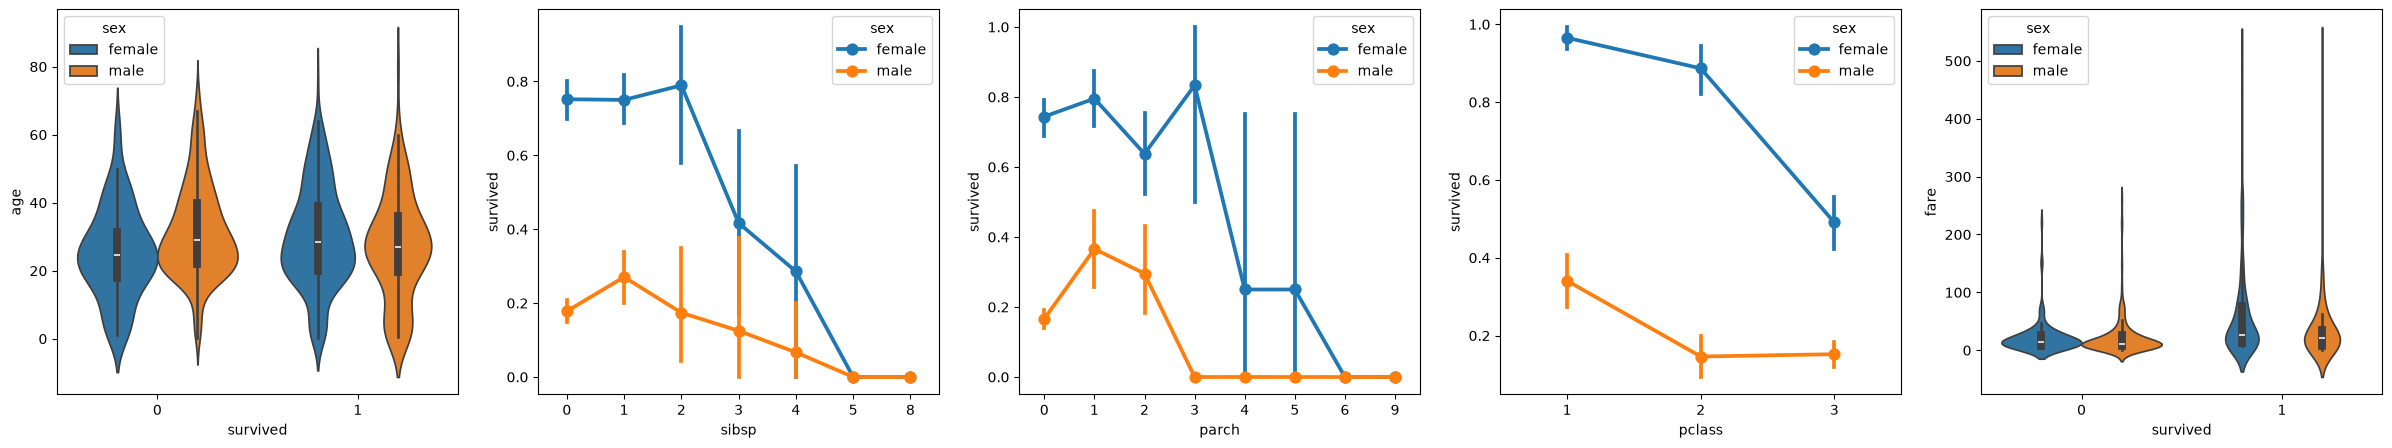

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(ncols=5, figsize=(30,5))
sns.violinplot(x="survived", y="age", hue="sex", data=df, ax=axs[0])
sns.pointplot(x="sibsp", y="survived", hue="sex", data=df, ax=axs[1])
sns.pointplot(x="parch", y="survived", hue="sex", data=df, ax=axs[2])
sns.pointplot(x="pclass", y="survived", hue="sex", data=df, ax=axs[3])
sns.violinplot(x="survived", y="fare", hue="sex", data=df, ax=axs[4])

In [4]:
df.replace({'male': 1, 'female': 0}, inplace=True)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",0,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",1,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",0,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",1,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",0,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",0,14.50,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",0,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",1,26.50,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",1,27.00,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [5]:
df.corr(numeric_only=True).abs()[["survived"]]

,survived
pclass,0.312469
survived,1.000000
age,0.055512
sibsp,0.027825
parch,0.082660
fare,0.244265
body,NaN


In [8]:
df = df[['sex', 'pclass','age','sibsp','fare','survived']].dropna()
df

,sex,pclass,age,sibsp,fare,survived
0,0,1,29.00,0,211.3375,1
1,1,1,0.92,1,151.5500,1
2,0,1,2.00,1,151.5500,0
3,1,1,30.00,1,151.5500,0
4,0,1,25.00,1,151.5500,0
...,...,...,...,...,...,...
1301,1,3,45.50,0,7.2250,0
1304,0,3,14.50,1,14.4542,0
1306,1,3,26.50,0,7.2250,0
1307,1,3,27.00,0,7.2250,0
